In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
from sklearn.cluster import KMeans

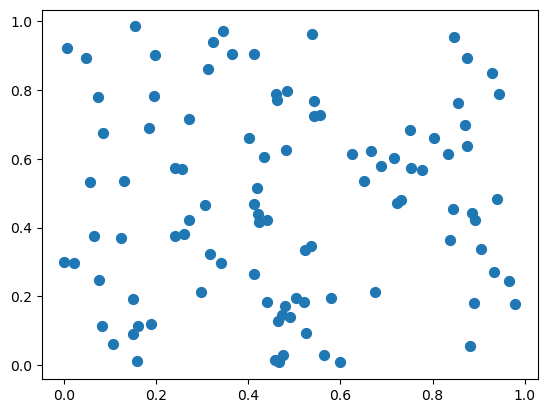

In [3]:
X = np.random.rand(100,2)
plt.scatter(X[:,0],X[:,1],s = 50)

In [4]:
#請KMeans分成幾類
km = KMeans(n_clusters = 4)

In [5]:
#開始訓練！
km.fit(X)

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4)

In [6]:
#取得預測結果
km.labels_

array([0, 1, 2, 0, 2, 1, 3, 1, 2, 3, 2, 2, 0, 2, 3, 1, 2, 2, 2, 3, 2, 0,
       2, 1, 3, 0, 1, 0, 2, 0, 0, 1, 0, 3, 1, 2, 1, 1, 3, 3, 2, 1, 1, 2,
       1, 1, 0, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 0, 0, 3, 0, 3, 2, 0, 0, 3,
       1, 1, 0, 0, 3, 0, 0, 2, 2, 1, 1, 3, 3, 1, 3, 2, 3, 0, 3, 2, 1, 1,
       2, 2, 3, 0, 2, 2, 0, 3, 0, 2, 3, 0])

In [7]:
# The lowest SSE value
km.inertia_

3.9865151593872565

In [8]:
# Final locations of the centroid
km.cluster_centers_

array([[0.32810353, 0.80682852],
       [0.8250597 , 0.56416521],
       [0.21830327, 0.33018341],
       [0.54775983, 0.14582589]])

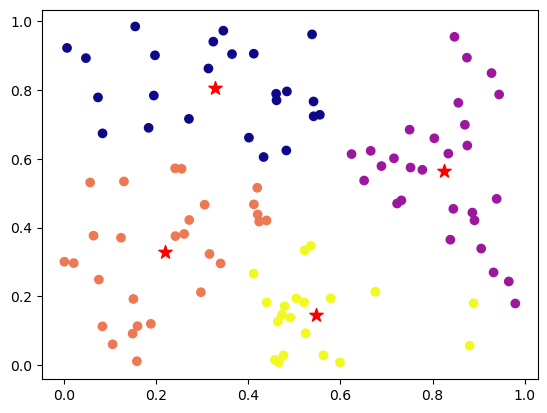

In [9]:
#plotting
plt.scatter(X[:,0],X[:,1], c=km.labels_,cmap='plasma')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], 
           marker="*", c="r", s=100, label="centroids")

In [10]:
from collections import Counter
Counter(km.labels_)

Counter({0: 24, 1: 28, 2: 28, 3: 20})

In [11]:
from yellowbrick.cluster import KElbowVisualizer

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

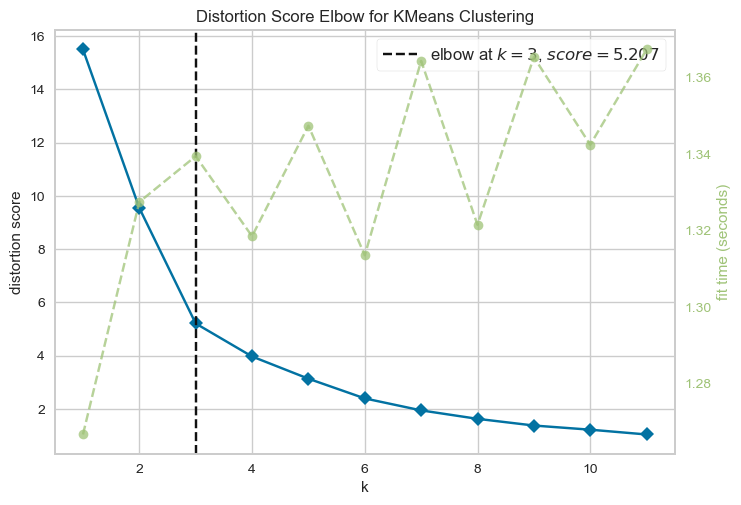

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [12]:
visualizer = KElbowVisualizer(km, k=(1,12)).fit(X)
visualizer.show()

In [13]:
# 監督式學習，有正確答案
# 非監督式學習，沒有答案
# k mean一定要用數值資料

In [14]:
# load precipitation data
prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
prec = prec.sel(time = slice('1980', '2020')) 
prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 492, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1980-01-01 1980-02-01 ... 2021-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.2534 0.2608 0.2638
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

In [15]:
prec_ta = prec.sel(lat = slice(10,30), lon = slice(100,140))
prec_ta_mean = prec_ta.mean(dim = ['lon', 'lat'])
prec_ta_mean

<xarray.Dataset>
Dimensions:    (time: 492, nv: 2)
Coordinates:
  * time       (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1980-01-01 1980-02-01 ... 2021-01-01
    lat_bnds   (nv) float32 18.75 21.25
    lon_bnds   (nv) float32 118.8 121.2
    precip     (time) float32 1.98 1.888 2.188 3.494 ... 7.17 8.15 4.494 3.631

In [16]:
prec_ta_mean["precip"]

<xarray.DataArray 'precip' (time: 492)>
array([ 1.9795988,  1.8882241,  2.1884189,  3.4940262,  5.2919974,
        5.641485 ,  6.444646 ,  6.300502 ,  7.3865047,  5.28694  ,
        3.613304 ,  3.3040614,  2.7720747,  1.5803673,  2.0610745,
        3.1328433,  5.8124866,  7.856506 ,  8.094843 ,  7.3024206,
        5.9582396,  5.5716906,  4.70833  ,  2.482038 ,  1.9424746,
        2.48604  ,  1.9844797,  3.608193 ,  4.824264 ,  7.544737 ,
        6.800213 ,  7.5467033,  6.877617 ,  3.834086 ,  3.8313727,
        2.2560263,  2.1137729,  2.354079 ,  2.760849 ,  2.5563157,
        5.0673294,  5.88389  ,  5.3176594,  8.628848 ,  5.372527 ,
        6.9978557,  5.115802 ,  3.187306 ,  2.3069732,  1.8128362,
        2.279729 ,  4.2228374,  6.3315077,  8.245799 ,  4.9123096,
       11.475758 ,  5.152726 ,  6.1199536,  3.8703132,  2.5627794,
        2.6533313,  2.8114288,  2.088468 ,  3.7399993,  4.2515044,
        8.418651 ,  4.4851785, 10.368483 ,  6.657441 ,  5.7724543,
        4.0472355,  2.863058 ,  1.8296328,  2.29778  ,  2.251424 ,
        2.9157557,  6.2325683,  6.8928847,  6.689397 ,  8.079259 ,
        5.244015 ,  5.1920996,  4.2106304,  1.9953023,  1.4899073,
        1.1892107,  1.9700667,  2.5082736,  4.319788 ,  7.3033004,
        6.709059 ,  6.940705 ,  7.1556797,  4.741556 ,  5.1971817,
        2.130962 ,  1.7089672,  1.984541 ,  2.0527802,  3.4714367,
...
        2.821497 ,  2.3393562,  1.4278517,  2.1974297,  3.2710872,
        5.2863946,  7.700047 ,  6.292429 ,  8.531073 ,  8.316171 ,
        6.6320724,  3.7290063,  2.8239057,  2.187218 ,  1.2174944,
        2.109905 ,  2.8467724,  4.813859 ,  8.06715  ,  9.394498 ,
        7.384388 ,  6.659589 ,  5.228935 ,  4.766119 ,  3.1339831,
        2.1599782,  1.2226208,  1.4280132,  2.7825642,  4.7756596,
        4.9491577,  9.947541 ,  7.3380384,  6.065899 ,  4.5406523,
        3.0397315,  3.4265363,  2.976105 ,  1.5412922,  2.6422062,
        3.1165738,  5.179313 ,  6.218933 ,  5.9757175,  9.0890875,
        8.414963 ,  6.479248 ,  4.3433075,  3.9512358,  2.8509927,
        2.4020176,  2.6534104,  2.992924 ,  6.4128437,  7.2989054,
        7.485103 ,  6.5780487,  6.5440607,  7.6482754,  3.8167644,
        3.682654 ,  2.810392 ,  2.0516088,  2.2613473,  2.531054 ,
        3.255993 ,  9.216282 ,  9.188361 ,  9.933779 ,  7.569716 ,
        4.092879 ,  3.1794426,  3.4253786,  1.8605717,  1.3834194,
        1.8686771,  2.9884748,  5.0956087,  7.2665534,  7.892214 ,
        9.76433  ,  7.93764  ,  3.6701808,  4.51867  ,  2.2883246,
        2.1269538,  1.7762928,  2.4205847,  2.7606373,  5.6722097,
        6.149811 ,  5.7258964,  7.996361 ,  7.1703033,  8.149907 ,
        4.4936004,  3.6312442], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01

In [17]:
# load temperature data
temp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\air.mon.mean.nc")
temp = temp.sel(time = slice('1980', '2020')) 
temp.load()

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
Data variables:
    air      (time, lat, lon) float32 -26.17 -26.17 -26.17 ... -22.16 -22.16
Attributes:
    description:    Data from NCEP initialized reanalysis (4x/day).  These ar...
    platform:       Model
    Conventions:    COARDS
    NCO:            20121012
    history:        Thu May  4 20:11:16 2000: ncrcat -d time,0,623 /Datasets/...
    title:          monthly mean air.sig995 from the NCEP Reanalysis
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...

In [18]:
temp["air"]

<xarray.DataArray 'air' (time: 492, lat: 73, lon: 144)>
array([[[-26.165155, -26.165155, -26.165155, ..., -26.165155,
         -26.165155, -26.165155],
        [-26.668064, -26.67064 , -26.6729  , ..., -26.709995,
         -26.689026, -26.675154],
        [-28.262897, -28.075802, -27.898706, ..., -28.848387,
         -28.65967 , -28.46322 ],
        ...,
        [-22.334515, -22.12612 , -21.912895, ..., -22.731607,
         -22.655159, -22.512896],
        [-21.80064 , -21.821926, -21.839352, ..., -21.651287,
         -21.71161 , -21.75838 ],
        [-23.001286, -23.001286, -23.001286, ..., -23.001286,
         -23.001286, -23.001286]],

       [[-30.588621, -30.588621, -30.588621, ..., -30.588621,
         -30.588621, -30.588621],
        [-31.089308, -31.078964, -31.081722, ..., -31.107239,
         -31.099651, -31.093443],
        [-31.412066, -31.200686, -30.980343, ..., -31.869654,
         -31.745512, -31.592758],
...
        [-26.182514, -26.095018, -26.010015, ..., -26.315847,
         -26.307514, -26.260014],
        [-27.652515, -27.681683, -27.700846, ..., -27.485016,
         -27.555851, -27.611681],
        [-28.065847, -28.065847, -28.065847, ..., -28.065847,
         -28.065847, -28.065847]],

       [[-22.444365, -22.444365, -22.444365, ..., -22.444365,
         -22.444365, -22.444365],
        [-22.798405, -22.686308, -22.570984, ..., -23.137108,
         -23.025013, -22.908888],
        [-24.933077, -24.498404, -24.077435, ..., -26.208075,
         -25.789534, -25.359694],
        ...,
        [-19.794363, -19.715332, -19.637913, ..., -19.85163 ,
         -19.87017 , -19.849201],
        [-20.690332, -20.747593, -20.787107, ..., -20.471785,
         -20.55727 , -20.62501 ],
        [-22.157272, -22.157272, -22.157272, ..., -22.157272,
         -22.157272, -22.157272]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
Attributes:
    long_name:     Monthly Mean Air Temperature at sigma level 0.995
    valid_range:   [-2000.  2000.]
    units:         degC
    precision:     1
    var_desc:      Air Temperature
    statistic:     Mean
    parent_stat:   Individual Obs
    dataset:       NCEP Reanalysis Derived Products
    level_desc:    0.995 sigma
    actual_range:  [-73.78001  42.14595]

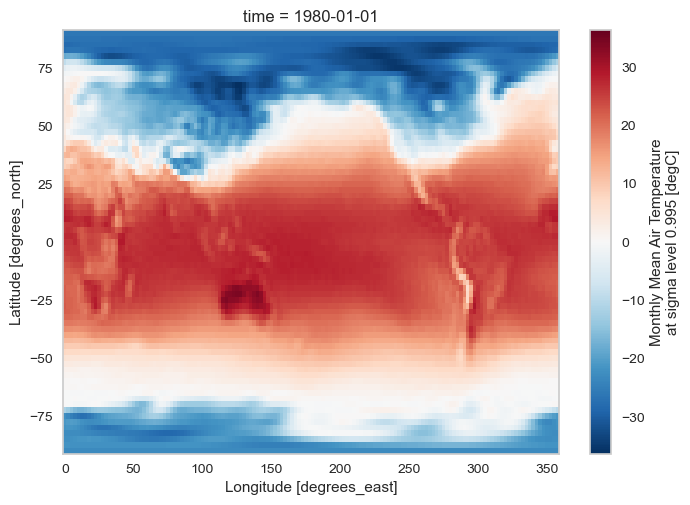

In [20]:
temp["air"][0, :, :].plot()

In [21]:
temp_ta = temp.sel(lat = slice(30,10), lon = slice(100,140))
temp_ta_mean = temp_ta.mean(dim = ['lon', 'lat'])
temp_ta_mean

<xarray.Dataset>
Dimensions:  (time: 492)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
Data variables:
    air      (time) float32 18.63 18.49 21.25 22.85 ... 25.88 23.89 22.51 19.86

In [22]:
xtime = prec_ta_mean['time']
nt = len(xtime)
xts = np.arange(0, nt, 1)

In [23]:
prec_ta_mean["precip"].shape

(492,)

In [24]:
temp_ta_mean["air"].shape

(492,)

In [25]:
import numpy as np
#comX=[xts,prec_ta_mean["precip"]]
comX = [prec_ta_mean["precip"],temp_ta_mean["air"]]
X1 = np.transpose(comX)

In [26]:
X1.shape

(492, 2)

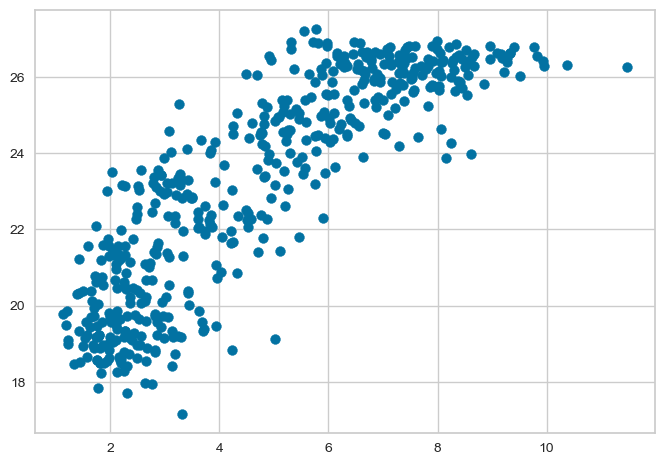

In [32]:
plt.scatter(X1[:,0],X1[:,1],s = 50)

In [33]:
from yellowbrick.cluster import KElbowVisualizer

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

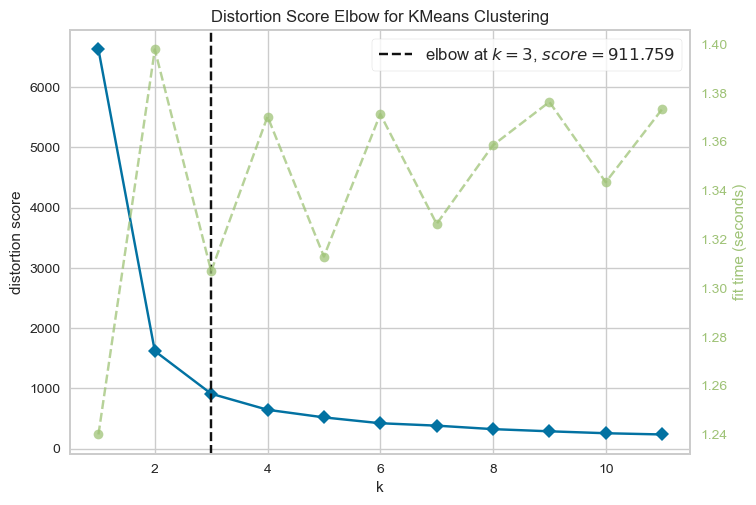

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [34]:
visualizer = KElbowVisualizer(km1, k=(1,12)).fit(X1)
visualizer.show()

In [35]:
#請KMeans分成幾類
km1 = KMeans(n_clusters = 3)

In [36]:
km1.fit(X1)

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=3)

In [38]:
km1.labels_

array([0, 0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 1, 1, 1, 1, 2,
       2, 0, 0, 0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 1, 1, 1,
       1, 1, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2, 2, 1,
       2, 1, 1, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2,
       2, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 2, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 2, 2, 0,
       0, 0, 0, 2, 2, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 2, 2, 1, 1, 1, 1, 2,
       0, 0, 0, 0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1,
       1, 2, 0, 0, 0, 0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 1, 2,
       1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 1, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2,
       1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 2, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 0,
       0, 2, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 2, 2, 0,
       0, 0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 2,
       2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 2, 2, 0, 0,

In [39]:
km1.inertia_

911.7589111328125

In [40]:
km1.cluster_centers_

array([[ 2.34554  , 19.807138 ],
       [ 7.3485966, 26.036999 ],
       [ 4.227132 , 23.482872 ]], dtype=float32)

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\IPython\core\events.py:89: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from current font.
  func(*args, **kwargs)
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


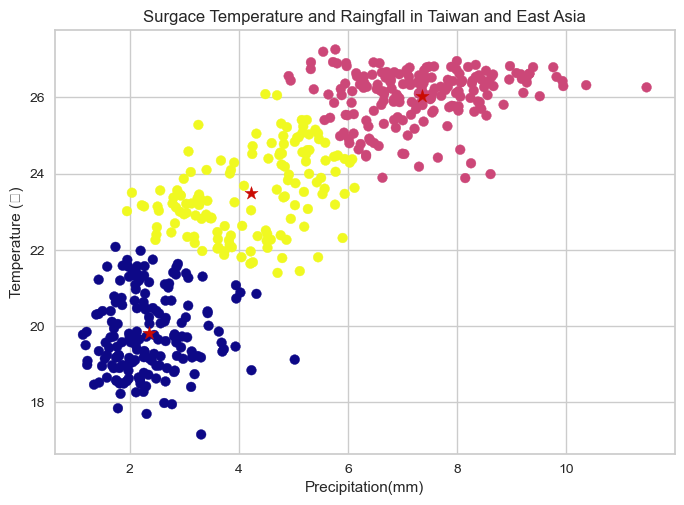

In [50]:
#plotting
plt.scatter(X1[:,0],X1[:,1], c = km1.labels_,cmap='plasma')
plt.xlabel("Precipitation(mm)")
plt.ylabel("Temperature (℃)")
plt.title ("Surgace Temperature and Raingfall in Taiwan and East Asia")
plt.scatter(km1.cluster_centers_[:,0], km1.cluster_centers_[:,1], 
           marker="*", c="r", s=100, label="centroids")